In [8]:
import pandas as pd 

df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.shape

(284807, 31)

In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

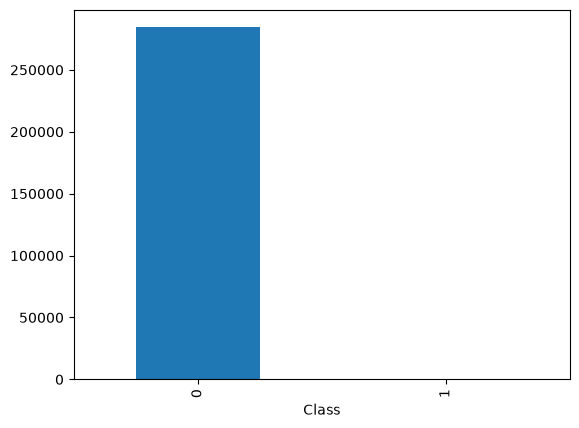

In [12]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.show()

In [13]:
X = df.drop('Class',axis =1)
y = df['Class']

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size =0.2,random_state =42
)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[['Amount','Time']] = scaler.fit_transform(
    X_train[['Amount','Time']]
)

X_test[['Amount','Time']] = scaler.transform(
    X_test[['Amount','Time']]
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.58      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
import pickle

pickle.dump(model, open('model/fraud_model.pkl', 'wb'))

FileNotFoundError: [Errno 2] No such file or directory: 'model/fraud_model.pkl'

In [22]:
import pickle

pickle.dump(model, open('../model/fraud_model.pkl', 'wb'))

In [23]:
pickle.dump(scaler, open('../model/scaler.pkl', 'wb'))

In [24]:
print(confusion_matrix(y_test, y_pred))

NameError: name 'confusion_matrix' is not defined

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.58      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [29]:
y_pred = model.predict(X_test)

# Step 3 - Your line ✅
print(classification_report(y_test, y_pred))

IndexError: list index out of range

In [31]:
# Step 1 - Retrain with class_weight='balanced'
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Step 2 - Predict
y_pred = model.predict(X_test)

# Step 3 - Your line ✅
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.76      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [32]:
y_proba = model.predict_proba(X_test)[:, 1]

for thresh in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_proba >= thresh).astype(int)
    r = classification_report(y_test, y_pred_t, output_dict=True)
    print(f"Threshold {thresh:.1f} → Precision: {r['1']['precision']:.2f}  Recall: {r['1']['recall']:.2f}  F1: {r['1']['f1-score']:.2f}")

Threshold 0.5 → Precision: 0.99  Recall: 0.76  F1: 0.86
Threshold 0.4 → Precision: 0.97  Recall: 0.79  F1: 0.87
Threshold 0.3 → Precision: 0.93  Recall: 0.83  F1: 0.88
Threshold 0.2 → Precision: 0.91  Recall: 0.86  F1: 0.88


In [33]:
# Final prediction with chosen threshold
y_final = (y_proba >= 0.3).astype(int)
print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
import joblib

joblib.dump(model, 'fraud_model.pkl')

# To load later
model = joblib.load('fraud_model.pkl')

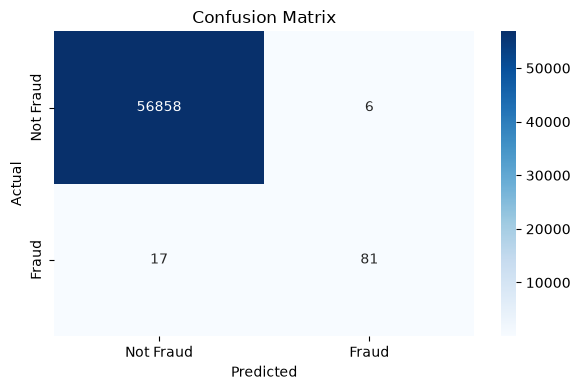

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_final = (y_proba >= 0.3).astype(int)
cm = confusion_matrix(y_test, y_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

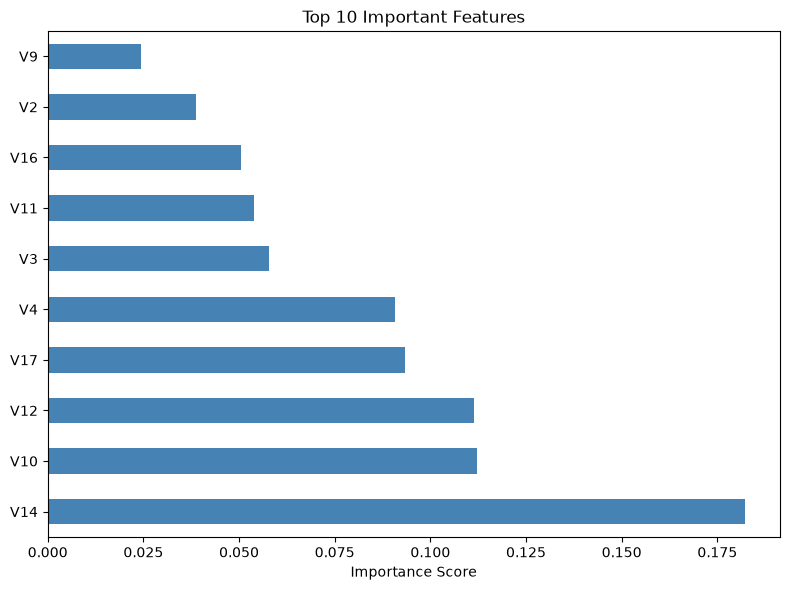

In [37]:
import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(8,6))
feat_imp.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [38]:
# Drop bottom features and see if model gets leaner/faster
weak = ['V9', 'V2', 'V16']
X_train_reduced = X_train.drop(columns=weak)
X_test_reduced = X_test.drop(columns=weak)

model2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model2.fit(X_train_reduced, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [39]:
y_final = (y_proba >= 0.3).astype(int)
print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

